# ML algoritmų ir skirtingu možymių sudarymo metodų taikymas klasifiekuojant į emocines klases #

In [272]:
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
import xgboost as XGB
from docx import Document
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


## DUOMENŲ NUSKAITYMAS ##

In [273]:
def read_text(path):
    doc = Document(path)
    return "\n".join(p.text.strip() for p in doc.paragraphs if p.text.strip())

def build_df(paths, label):
    texts = []
    
    for path in paths:
        full_text = read_text(path)
        sentences = [s.strip() for s in full_text.split("\n") if s.strip()]
        
        for s in sentences:
            texts.append({
                "sentence": s,
                "label": label
            })
    
    return pd.DataFrame(texts)

In [274]:
D_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\DŽIAUGSMAS_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\DŽIAUGSMAS_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\DŽIAUGSMAS_3_4_2026.docx",
]

L_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\LIŪDESYS_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\LIŪDESYS_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\LIŪDESYS_3_4_2026.docx",
]

N_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NUOSTABA_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NUOSTABA_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NUOSTABA_3_4_2026.docx",
]

P_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\PYKTIS_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\PYKTIS_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\PYKTIS_3_4_2026.docx",
]

Z_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NEUTRALUS_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NEUTRALUS_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NEUTRALUS_3.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NEUTRALUS_2026_1.docx",
]

In [275]:
df = pd.concat([
    build_df(D_paths, "džiaugsmas"),
    build_df(L_paths, "liūdesys"),
    build_df(N_paths, "nuostaba"),
    build_df(P_paths, "pyktis"),
    build_df(Z_paths, "neutralus"),
], ignore_index=True)

In [276]:
print(df)


                                               sentence       label
0                        – Matai, kiek žibuoklių radau!  džiaugsmas
1                     Puikus buvo tada metas, vyručiai!  džiaugsmas
2              O dabar metas į puotą, kuri mūsų laukia!  džiaugsmas
3                          Linksminkitės, mano draugai!  džiaugsmas
4                                         – Kaip gražu!  džiaugsmas
...                                                 ...         ...
6936  Visgi, tėveliai dažniausiai išreiškia didelį d...   neutralus
6937  – Kaip vertinate bendrą etninės kultūros ugdym...   neutralus
6938  – Šia linkme nesu atlikusi specialių tyrimų, t...   neutralus
6939  Juk be mokyklos, be ugdymo įstaigų, visko prad...   neutralus
6940  Netgi, jei mokykloje ir nėra etninės kultūros ...   neutralus

[6941 rows x 2 columns]


### PATIKRINIMAS DĖK DUBLIKATŲ ###

In [277]:
print('Viso eilučių skaičius:', len(df))

print('Dublikatų skaičius:',
      df.duplicated(subset=["sentence"]).sum())

print('Unikalių eilučių skaičius:',
      df["sentence"].nunique())

print('Dublikatai pagal kiekvieną emocija:',
      df.groupby("label")["sentence"]
        .apply(lambda x: x.duplicated().sum()))


Viso eilučių skaičius: 6941
Dublikatų skaičius: 0
Unikalių eilučių skaičius: 6941
Dublikatai pagal kiekvieną emocija: label
džiaugsmas    0
liūdesys      0
neutralus     0
nuostaba      0
pyktis        0
Name: sentence, dtype: int64


## STEBĖJIMŲ SKAIČIUS ##

label
džiaugsmas    1628
pyktis        1544
nuostaba      1522
neutralus     1172
liūdesys      1075
Name: count, dtype: int64
label
džiaugsmas    0.234548
pyktis        0.222446
nuostaba      0.219277
neutralus     0.168852
liūdesys      0.154877
Name: proportion, dtype: float64


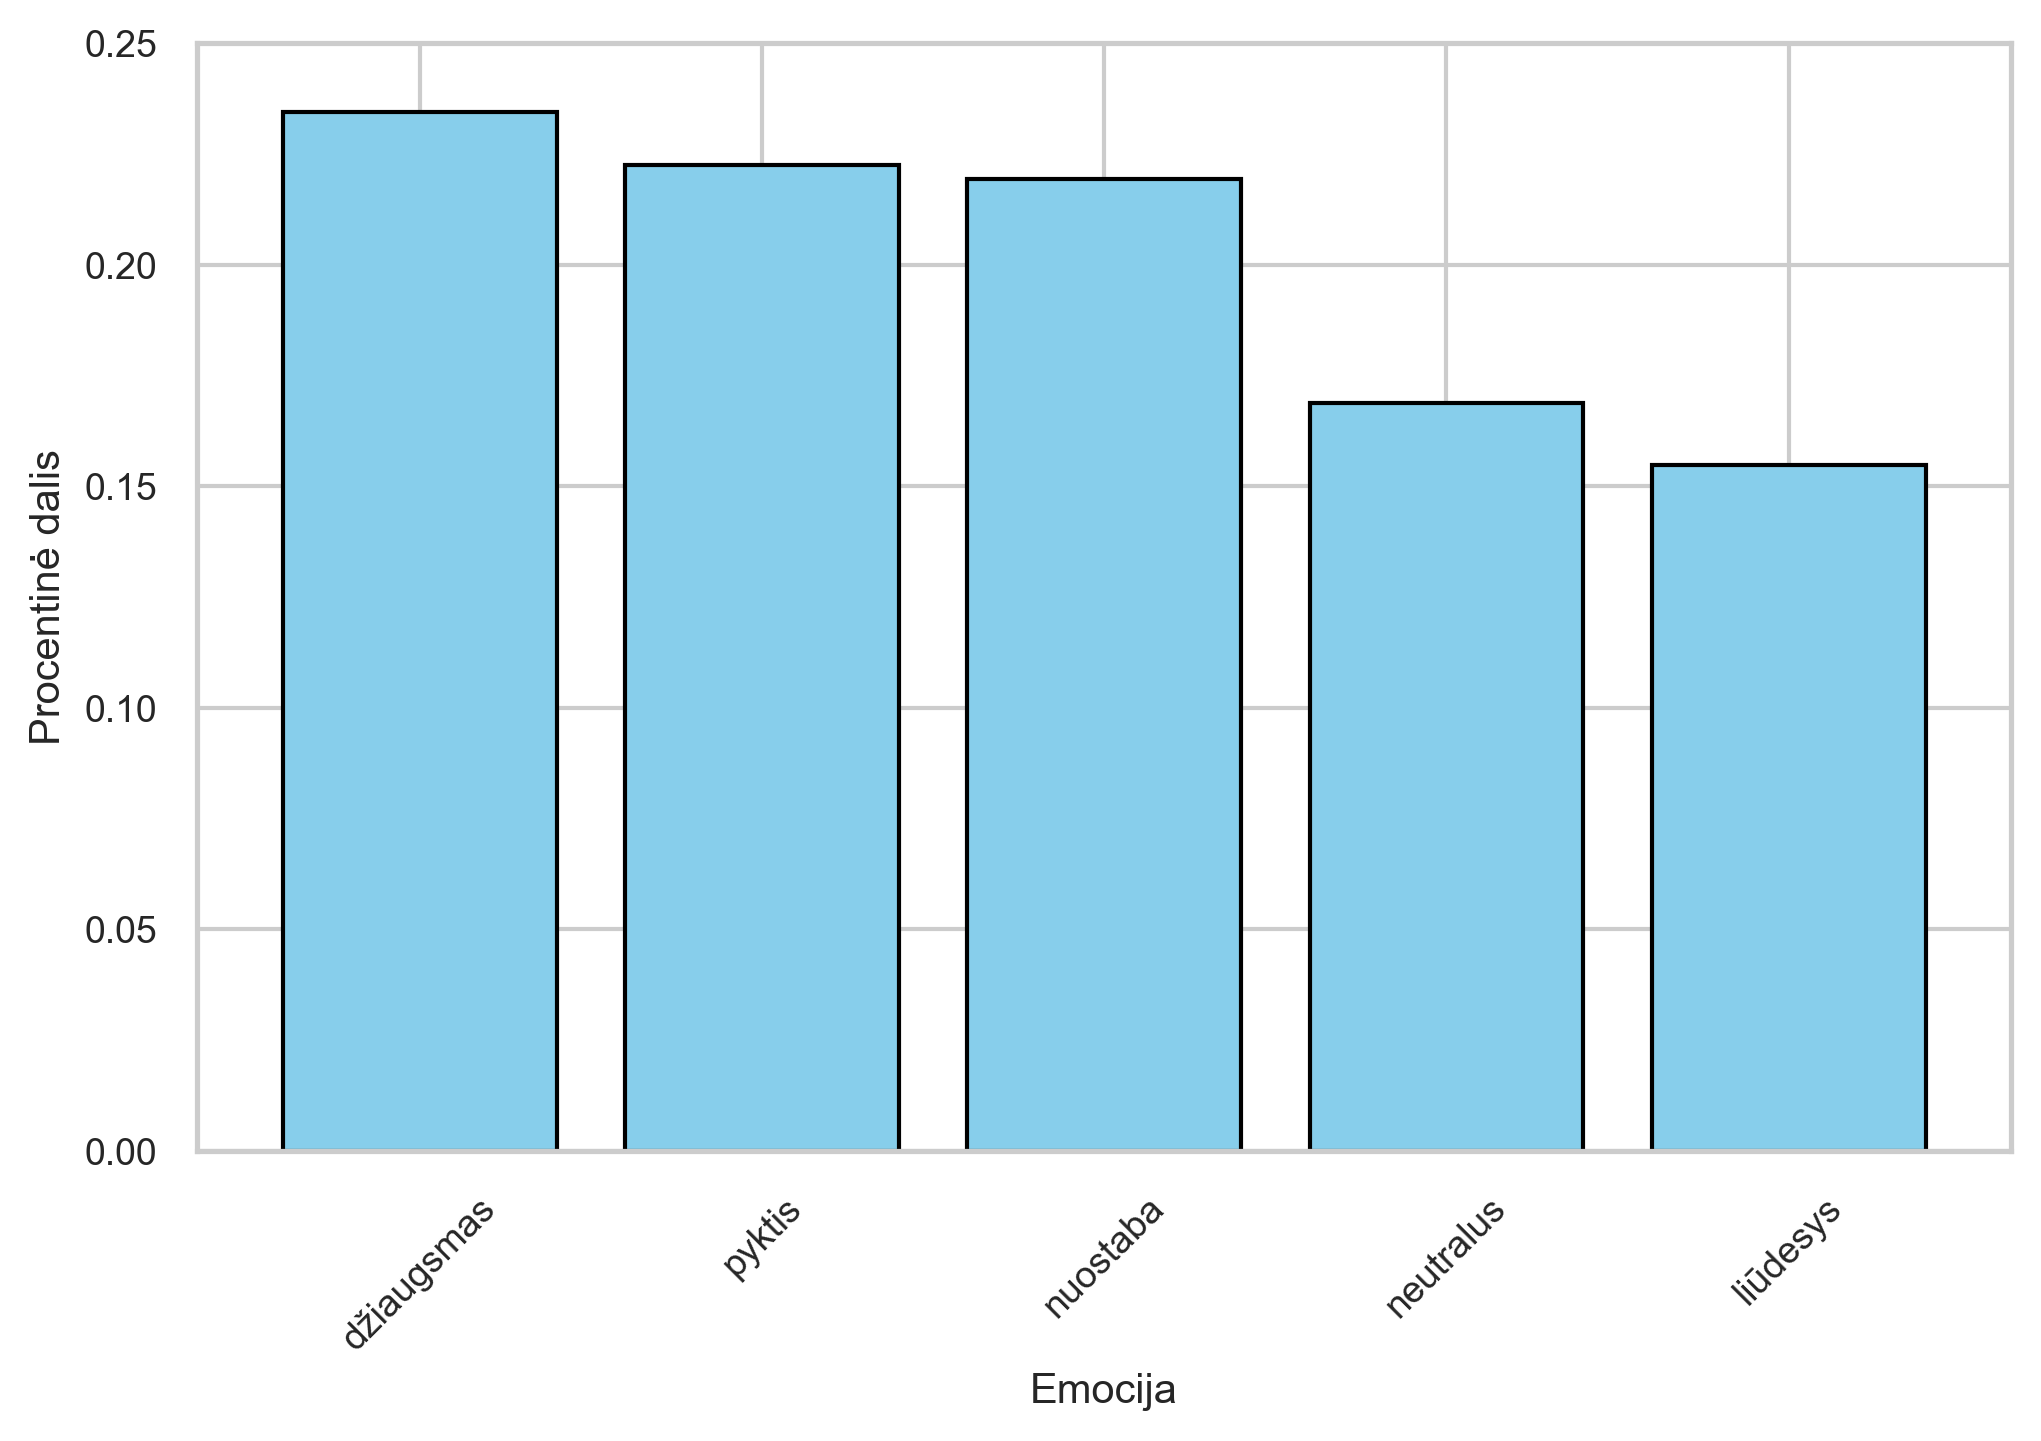

In [278]:
label_counts = df['label'].value_counts().sort_values(ascending=False)
label_count_normalized = df['label'].value_counts(normalize=True).sort_values(ascending=False)
print(label_counts)
print(label_count_normalized)

plt.figure(figsize=(7, 5), dpi=300)

label_count_normalized.plot(
    kind="bar",
    color="skyblue",         
    edgecolor="black",
    width=0.8
)
plt.xlabel("Emocija", fontsize=10)
plt.ylabel("Procentinė dalis", fontsize=10)
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 0.25)
#plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("emociju_skaičius.png", bbox_inches="tight", dpi=300)
plt.show()


## LINGVIT. IR MORFOLOG. POŽYMIŲ SUDARYMAS ##

In [193]:
import spacy
nlp = spacy.load("lt_core_news_sm")

def preprocess_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return " ".join(tokens)

df['processed_sentence'] = df['sentence'].apply(preprocess_text)

In [194]:
from collections import Counter

def text_features(text: str) -> dict:
    if text is None:
        text = ""
    doc = nlp(text)

    tokens = [t for t in doc if not t.is_space]
    words = [t for t in tokens if t.is_alpha]
    n_tokens = len(tokens)
    n_words = len(words)
    n_chars = len(text)

    n_stop = sum(1 for t in words if t.is_stop)
    n_punct = sum(1 for t in tokens if t.is_punct)
    n_digits = sum(1 for t in tokens if t.like_num or t.is_digit)
    n_upper = sum(1 for t in tokens if t.text.isupper() and t.is_alpha)
    n_title = sum(1 for t in tokens if t.text.istitle())

    punct_counts = Counter(t.text for t in tokens if t.is_punct)
    n_excl = punct_counts.get("!", 0)
    n_q = punct_counts.get("?", 0)
    n_period = punct_counts.get(".", 0)
    n_comma = punct_counts.get(",", 0)
    n_colon = punct_counts.get(":", 0)
    n_semi = punct_counts.get(";", 0)

    pos_counts = Counter(t.pos_ for t in tokens)
    pos_feats = {
        "pos_NOUN": pos_counts.get("NOUN", 0),
        "pos_VERB": pos_counts.get("VERB", 0),
        "pos_ADJ": pos_counts.get("ADJ", 0),
        "pos_ADV": pos_counts.get("ADV", 0),
        "pos_PRON": pos_counts.get("PRON", 0),
        "pos_PROPN": pos_counts.get("PROPN", 0),
        "pos_ADP": pos_counts.get("ADP", 0),
        "pos_DET": pos_counts.get("DET", 0),
        "pos_CCONJ": pos_counts.get("CCONJ", 0),
        "pos_SCONJ": pos_counts.get("SCONJ", 0),
        "pos_PART": pos_counts.get("PART", 0),
        "pos_INTJ": pos_counts.get("INTJ", 0),
        "pos_SYM": pos_counts.get("SYM", 0),
        "pos_X": pos_counts.get("X", 0),
    }

    avg_word_len = (sum(len(t.text) for t in words) / n_words) if n_words else 0.0

    feats = {
        "n_chars": n_chars,
        "n_tokens": n_tokens,
        "n_words": n_words,
        "n_stopwords": n_stop,
        "n_punct": n_punct,
        "n_digits": n_digits,
        "n_upper_words": n_upper,
        "n_title_words": n_title,
        "avg_word_len": avg_word_len,

        "n_exclamation": n_excl,
        "n_question": n_q,
        "n_period": n_period,
        "n_comma": n_comma,
        "n_colon": n_colon,
        "n_semicolon": n_semi,

    }

    feats.update(pos_feats)
    return feats


feat_df = df["sentence"].fillna("").apply(text_features).apply(pd.Series)

df_bendras = pd.concat([df, feat_df], axis=1)


In [195]:
print(df_bendras)

                                               sentence       label  \
0                        – Matai, kiek žibuoklių radau!  džiaugsmas   
1                     Puikus buvo tada metas, vyručiai!  džiaugsmas   
2              O dabar metas į puotą, kuri mūsų laukia!  džiaugsmas   
3                          Linksminkitės, mano draugai!  džiaugsmas   
4                                         – Kaip gražu!  džiaugsmas   
...                                                 ...         ...   
6936  Visgi, tėveliai dažniausiai išreiškia didelį d...   neutralus   
6937  – Kaip vertinate bendrą etninės kultūros ugdym...   neutralus   
6938  – Šia linkme nesu atlikusi specialių tyrimų, t...   neutralus   
6939  Juk be mokyklos, be ugdymo įstaigų, visko prad...   neutralus   
6940  Netgi, jei mokykloje ir nėra etninės kultūros ...   neutralus   

                                     processed_sentence  n_chars  n_tokens  \
0                                Matai žibuoklius radau     30.0     

## DUOMENŲ SKAIDYMAS ##

In [196]:
df_train, df_test = train_test_split(df_bendras, test_size=0.2, random_state=0, stratify=df_bendras["label"])

y_train = df_train["label"]
y_test = df_test["label"]

y_train_enc = y_train.astype("category").cat.codes
y_test_enc = y_test.astype("category").cat.codes

X_train_text = df_train["processed_sentence"]
X_test_text = df_test["processed_sentence"]

X_train_feats = df_train.drop(columns=["sentence", "processed_sentence", "label"])
X_test_feats = df_test.drop(columns=["sentence", "processed_sentence", "label"])

X_train_combined = pd.concat([X_train_text, X_train_feats], axis=1)
X_test_combined = pd.concat([X_test_text, X_test_feats], axis=1)

text_stulp = "processed_sentence"
skait_stulp = X_train_feats.columns.tolist()

X_text = df_bendras["processed_sentence"]
X_feats = df_bendras[skait_stulp]
X_bendras = pd.concat([X_text, X_feats], axis=1)
y = df_bendras["label"]
y_enc = y.astype("category").cat.codes

In [197]:
df_bendras

,sentence,label,processed_sentence,n_chars,n_tokens,n_words,n_stopwords,n_punct,n_digits,n_upper_words,...,pos_PRON,pos_PROPN,pos_ADP,pos_DET,pos_CCONJ,pos_SCONJ,pos_PART,pos_INTJ,pos_SYM,pos_X
0,"– Matai, kiek žibuoklių radau!",džiaugsmas,Matai žibuoklius radau,30.0,7.0,4.0,1.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"Puikus buvo tada metas, vyručiai!",džiaugsmas,Puikus būti tada meti vyručis,33.0,7.0,5.0,0.0,2.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"O dabar metas į puotą, kuri mūsų laukia!",džiaugsmas,dabar metas puota laukti,40.0,10.0,8.0,4.0,2.0,0.0,1.0,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,"Linksminkitės, mano draugai!",džiaugsmas,Linksminkitės draugas,28.0,5.0,3.0,1.0,2.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,– Kaip gražu!,džiaugsmas,gražu,13.0,4.0,2.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6936,"Visgi, tėveliai dažniausiai išreiškia didelį d...",neutralus,tėveliai dažnai išreiškti didelis džiuguo vaik...,601.0,101.0,80.0,27.0,21.0,0.0,0.0,...,6.0,1.0,3.0,6.0,5.0,1.0,2.0,0.0,0.0,1.0
6937,– Kaip vertinate bendrą etninės kultūros ugdym...,neutralus,vertinate bendras etninis kultūra ugdymas situ...,68.0,10.0,8.0,1.0,2.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6938,"– Šia linkme nesu atlikusi specialių tyrimų, t...",neutralus,linkme nesas atlikti specialis tyrimas dažnai ...,424.0,72.0,59.0,21.0,13.0,1.0,0.0,...,2.0,0.0,2.0,4.0,5.0,4.0,3.0,0.0,0.0,0.0
6939,"Juk be mokyklos, be ugdymo įstaigų, visko prad...",neutralus,mokykla ugdymas įstaiga viskas pradžių prasti ...,295.0,51.0,43.0,17.0,8.0,0.0,0.0,...,4.0,0.0,6.0,1.0,4.0,0.0,2.0,0.0,0.0,4.0


In [198]:
print(skait_stulp)

['n_chars', 'n_tokens', 'n_words', 'n_stopwords', 'n_punct', 'n_digits', 'n_upper_words', 'n_title_words', 'avg_word_len', 'n_exclamation', 'n_question', 'n_period', 'n_comma', 'n_colon', 'n_semicolon', 'pos_NOUN', 'pos_VERB', 'pos_ADJ', 'pos_ADV', 'pos_PRON', 'pos_PROPN', 'pos_ADP', 'pos_DET', 'pos_CCONJ', 'pos_SCONJ', 'pos_PART', 'pos_INTJ', 'pos_SYM', 'pos_X']


## Naudojant tik lingvist ir morfolog požymius ##

### Logistinė regresija (LR) ###

In [199]:
pipe_lg_feat = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000))
])

param_grid_lg = {
    "clf__C": [0.1, 1, 5, 10],
    "clf__penalty": ['l2', 'l1'],
    "clf__solver": ['liblinear']
}

gs_lg_feat = GridSearchCV(
    pipe_lg_feat, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_feat.fit(X_train_feats, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [200]:
print("Optimalus parametrai:", gs_lg_feat.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_feat.best_score_)

'''cv_scores_lg_feat = cross_val_score(
    gs_lg_feat.best_estimator_,
    X_feats,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_lg_feat = gs_lg_feat.predict(X_test_feats)
print(classification_report(y_test, y_pred_lg_feat, digits=4))

Optimalus parametrai: {'clf__C': 5, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.6103772611480875
              precision    recall  f1-score   support

  džiaugsmas     0.6190    0.8374    0.7119       326
    liūdesys     0.5665    0.6140    0.5893       215
   neutralus     0.7054    0.7265    0.7158       234
    nuostaba     0.5851    0.3607    0.4462       305
      pyktis     0.5769    0.5340    0.5546       309

    accuracy                         0.6120      1389
   macro avg     0.6106    0.6145    0.6036      1389
weighted avg     0.6086    0.6120    0.6002      1389



### Atraminių vektorių (SVM) ###

In [201]:
pipe_svm_feat = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(max_iter=3000))
])

param_grid_svm = [
    {
        "clf__C": [0.1, 1, 5, 10],
        "clf__loss": ["hinge", "squared_hinge"],
        "clf__penalty": ["l2"],
    },
    {
        "clf__C": [0.1, 1, 5, 10],
        "clf__loss": ["squared_hinge"],
        "clf__penalty": ["l1"],
        "clf__dual": [False],       
}
]

gs_svm_feat = GridSearchCV(
    pipe_svm_feat, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_feat.fit(X_train_feats, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [202]:
print("Optimalus parametrai:", gs_svm_feat.best_params_)
print("Optimali f1_macro reikšmė:", gs_svm_feat.best_score_)

'''cv_scores_svm_feat = cross_val_score(
    gs_svm_feat.best_estimator_,
    X_feats,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_svm_feat = gs_svm_feat.predict(X_test_feats)
print(classification_report(y_test, y_pred_svm_feat, digits=4))

Optimalus parametrai: {'clf__C': 10, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l2'}
Optimali f1_macro reikšmė: 0.6020722240445873
              precision    recall  f1-score   support

  džiaugsmas     0.6048    0.8497    0.7066       326
    liūdesys     0.5542    0.6186    0.5846       215
   neutralus     0.6840    0.7308    0.7066       234
    nuostaba     0.6316    0.3148    0.4201       305
      pyktis     0.5709    0.5340    0.5518       309

    accuracy                         0.6062      1389
   macro avg     0.6091    0.6096    0.5940      1389
weighted avg     0.6087    0.6062    0.5904      1389



### Naivusis Bajesas (NB) ###

In [203]:
pipe_nb_feat = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", MultinomialNB())
])

param_grid_nb = [
        {"clf__alpha": np.arange(0.1, 2.1, 0.1)}
]

gs_nb_feat = GridSearchCV(
    pipe_nb_feat, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_feat.fit(X_train_feats, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,feature_range,"(0, ...)"


In [204]:
print("Optimalus parametrai:", gs_nb_feat.best_params_)
print("Geriausia f1_macro reikšmė:", gs_nb_feat.best_score_)

'''cv_scores_nb_feat = cross_val_score(
    gs_nb_feat.best_estimator_,
    X_feats,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_nb_feat = gs_nb_feat.predict(X_test_feats)
print(classification_report(y_test, y_pred_nb_feat, digits=4))


Optimalus parametrai: {'clf__alpha': 0.1}
Geriausia f1_macro reikšmė: 0.4778688695134429
              precision    recall  f1-score   support

  džiaugsmas     0.5323    0.9110    0.6719       326
    liūdesys     0.5000    0.0419    0.0773       215
   neutralus     0.7191    0.5470    0.6214       234
    nuostaba     0.3775    0.5049    0.4320       305
      pyktis     0.5683    0.4175    0.4813       309

    accuracy                         0.5162      1389
   macro avg     0.5394    0.4845    0.4568      1389
weighted avg     0.5328    0.5162    0.4763      1389



### XGBoost (XGB) ###

In [205]:
pipe_xgb_feat = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGB.XGBClassifier())
])

param_grid_xgb = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.01, 0.1],  
    "clf__eval_metric": ["mlogloss", "logloss"]
}

gs_xgb_feat = GridSearchCV(
    pipe_xgb_feat, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_xgb_feat.fit(X_train_feats, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [206]:
print("Optimalus parametrai:", gs_xgb_feat.best_params_)
print("Geriausia f1_macro reikšmė:", gs_xgb_feat.best_score_)

'''cv_scores_xgb_feat = cross_val_score(
    gs_xgb_feat.best_estimator_,
    X_feats,
    y_enc,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_xgb_feat = gs_xgb_feat.predict(X_test_feats)
print(classification_report(y_test_enc, y_pred_xgb_feat, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.6558193811633022
              precision    recall  f1-score   support

           0     0.6769    0.8098    0.7374       326
           1     0.6195    0.5907    0.6048       215
           2     0.7585    0.7650    0.7617       234
           3     0.6000    0.5410    0.5690       305
           4     0.6007    0.5502    0.5743       309

    accuracy                         0.6515      1389
   macro avg     0.6511    0.6513    0.6494      1389
weighted avg     0.6479    0.6515    0.6477      1389



### Atsitiktinių miškų (RF) ###

In [207]:
pipe_rf_feat = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=0))
])

param_grid_rf = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [3, 5],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2]
}

gs_rf_feat = GridSearchCV(
    pipe_rf_feat, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_feat.fit(X_train_feats, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [208]:
print("Optimalus parametrai:", gs_rf_feat.best_params_)
print("Geriausia f1_macro reikšmė:", gs_rf_feat.best_score_)

'''cv_scores_rf_feat = cross_val_score(
    gs_rf_feat.best_estimator_,
    X_feats,
    y,
    cv=5,
    scoring="f1_macro"
)'''


y_pred_rf_feat = gs_rf_feat.predict(X_test_feats)
print(classification_report(y_test, y_pred_rf_feat, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.6080426255668521
              precision    recall  f1-score   support

  džiaugsmas     0.6074    0.8589    0.7116       326
    liūdesys     0.6037    0.4605    0.5224       215
   neutralus     0.7250    0.7436    0.7342       234
    nuostaba     0.5411    0.5180    0.5293       305
      pyktis     0.6379    0.4790    0.5471       309

    accuracy                         0.6184      1389
   macro avg     0.6230    0.6120    0.6089      1389
weighted avg     0.6189    0.6184    0.6095      1389



## NAUDOJANT TF-IDF IR BOW ##

### Logistinė regresija (LR) + TF-IDF ###

In [209]:
pipe_lg_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=3000))
])

gs_lg_tfidf_text = GridSearchCV(
    pipe_lg_tfidf_text, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_tfidf_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [210]:
print("Optimalus parametrai:", gs_lg_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_tfidf_text.best_score_)

'''cv_scores_lg_tfidf_text = cross_val_score(
    gs_lg_tfidf_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_lg_tfidf_text = gs_lg_tfidf_text.predict(X_test_text)
print(classification_report(y_test, y_pred_lg_tfidf_text, digits=4))

Optimalus parametrai: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.7355854564207982
              precision    recall  f1-score   support

  džiaugsmas     0.8062    0.8037    0.8049       326
    liūdesys     0.6927    0.6186    0.6536       215
   neutralus     0.7710    0.8632    0.8145       234
    nuostaba     0.7579    0.7082    0.7322       305
      pyktis     0.6708    0.7055    0.6877       309

    accuracy                         0.7423      1389
   macro avg     0.7397    0.7398    0.7386      1389
weighted avg     0.7420    0.7423    0.7411      1389



### Logistinė regresija (LR) + BOW ###

In [211]:
pipe_lg_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", LogisticRegression(max_iter=3000))
])

gs_lg_cv_text = GridSearchCV(
    pipe_lg_cv_text, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_cv_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [212]:
print("Optimalus parametrai:", gs_lg_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_cv_text.best_score_)

'''cv_scores_lg_cv_text = cross_val_score(
    gs_lg_cv_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_lg_cv_text = gs_lg_cv_text.predict(X_test_text)
print(classification_report(y_test, y_pred_lg_cv_text, digits=4))

Optimalus parametrai: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.7177100019071457
              precision    recall  f1-score   support

  džiaugsmas     0.7672    0.7883    0.7776       326
    liūdesys     0.7500    0.5581    0.6400       215
   neutralus     0.8592    0.7821    0.8188       234
    nuostaba     0.7354    0.7016    0.7181       305
      pyktis     0.6077    0.7670    0.6781       309

    accuracy                         0.7279      1389
   macro avg     0.7439    0.7194    0.7265      1389
weighted avg     0.7376    0.7279    0.7280      1389



### Atraminių vektorių (SVM) + TF-IDF ###

In [213]:
pipe_svm_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC(max_iter=3000))
])

gs_svm_tfidf_text = GridSearchCV(
    pipe_svm_tfidf_text, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_tfidf_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [214]:
print("Optimalus parametrai:", gs_svm_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_svm_tfidf_text.best_score_)

'''cv_scores_svm_tfidf_text = cross_val_score(
    gs_svm_tfidf_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''


y_pred_svm_tfidf_text = gs_svm_tfidf_text.predict(X_test_text)
print(classification_report(y_test, y_pred_svm_tfidf_text, digits=4))

Optimalus parametrai: {'clf__C': 1, 'clf__loss': 'hinge', 'clf__penalty': 'l2'}
Geriausia f1_macro reikšmė: 0.7384237338147079
              precision    recall  f1-score   support

  džiaugsmas     0.8185    0.8160    0.8172       326
    liūdesys     0.7330    0.6000    0.6598       215
   neutralus     0.7610    0.8846    0.8182       234
    nuostaba     0.7717    0.6984    0.7332       305
      pyktis     0.6676    0.7346    0.6995       309

    accuracy                         0.7502      1389
   macro avg     0.7504    0.7467    0.7456      1389
weighted avg     0.7517    0.7502    0.7484      1389



### Atraminių vektorių (SVM) + BOW ###

In [215]:
pipe_svm_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", LinearSVC(max_iter=3000))
])

gs_svm_cv_text = GridSearchCV(
    pipe_svm_cv_text, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_cv_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [216]:
print("Optimalus parametrai:", gs_svm_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_svm_cv_text.best_score_)

'''cv_scores_svm_cv_text = cross_val_score(
    gs_svm_cv_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_svm_cv_text = gs_svm_cv_text.predict(X_test_text)
print(classification_report(y_test, y_pred_svm_cv_text, digits=4))

Optimalus parametrai: {'clf__C': 0.1, 'clf__loss': 'hinge', 'clf__penalty': 'l2'}
Geriausia f1_macro reikšmė: 0.7237278534602458
              precision    recall  f1-score   support

  džiaugsmas     0.7640    0.7945    0.7789       326
    liūdesys     0.7500    0.5581    0.6400       215
   neutralus     0.8393    0.8034    0.8210       234
    nuostaba     0.7537    0.6721    0.7106       305
      pyktis     0.6015    0.7670    0.6743       309

    accuracy                         0.7264      1389
   macro avg     0.7417    0.7190    0.7249      1389
weighted avg     0.7361    0.7264    0.7262      1389



### Naivusis Bajesas (NB) + TF-IDF ###

In [217]:
pipe_nb_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

gs_nb_tfidf_text = GridSearchCV(
    pipe_nb_tfidf_text, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_tfidf_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [218]:
print("Optimalus parametrai:", gs_nb_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_nb_tfidf_text.best_score_)

'''cv_scores_nb_tfidf_text = cross_val_score(
    gs_nb_tfidf_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''


y_pred_nb_tfidf_text = gs_nb_tfidf_text.predict(X_test_text)
print(classification_report(y_test, y_pred_nb_tfidf_text, digits=4))

Optimalus parametrai: {'clf__alpha': 0.1}
Geriausia f1_macro reikšmė: 0.737887572604586
              precision    recall  f1-score   support

  džiaugsmas     0.7541    0.8466    0.7977       326
    liūdesys     0.7088    0.6000    0.6499       215
   neutralus     0.7419    0.8846    0.8070       234
    nuostaba     0.7418    0.6689    0.7034       305
      pyktis     0.7352    0.6828    0.7081       309

    accuracy                         0.7394      1389
   macro avg     0.7364    0.7366    0.7332      1389
weighted avg     0.7381    0.7394    0.7357      1389



### Naivusis Bajesas (NB) + BOW ###

In [219]:
pipe_nb_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", MultinomialNB())
])

gs_nb_cv_text = GridSearchCV(
    pipe_nb_cv_text, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_cv_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [220]:
print("Optimalus parametrai:", gs_nb_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_nb_cv_text.best_score_)

'''cv_scores_nb_cv_text = cross_val_score(
    gs_nb_cv_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''


y_pred_nb_cv_text = gs_nb_cv_text.predict(X_test_text)
print(classification_report(y_test, y_pred_nb_cv_text, digits=4))

Optimalus parametrai: {'clf__alpha': 0.30000000000000004}
Geriausia f1_macro reikšmė: 0.7431706613696315
              precision    recall  f1-score   support

  džiaugsmas     0.7976    0.8221    0.8097       326
    liūdesys     0.6432    0.6372    0.6402       215
   neutralus     0.7128    0.9017    0.7962       234
    nuostaba     0.7816    0.6689    0.7208       305
      pyktis     0.7173    0.6570    0.6858       309

    accuracy                         0.7365      1389
   macro avg     0.7305    0.7374    0.7305      1389
weighted avg     0.7381    0.7365    0.7341      1389



### XGBoost (XGB) + TF-IDF ###

In [221]:
pipe_xgb_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", XGB.XGBClassifier())
])


gs_xgb_tfidf_text = GridSearchCV(
    pipe_xgb_tfidf_text, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_xgb_tfidf_text.fit(X_train_text, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [222]:
print("Optimalus parametrai:", gs_xgb_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_xgb_tfidf_text.best_score_)

'''cv_scores_xgb_tfidf_text = cross_val_score(
    gs_xgb_tfidf_text.best_estimator_,
    X_text,
    y_enc,
    cv=5,
    scoring="f1_macro"
)'''


y_pred_xgb_tfidf_text = gs_xgb_tfidf_text.predict(X_test_text)
print(classification_report(y_test_enc, y_pred_xgb_tfidf_text, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.6413036360600612
              precision    recall  f1-score   support

           0     0.6847    0.6994    0.6920       326
           1     0.6596    0.4326    0.5225       215
           2     0.8000    0.6154    0.6957       234
           3     0.7639    0.5836    0.6617       305
           4     0.4880    0.7929    0.6042       309

    accuracy                         0.6393      1389
   macro avg     0.6793    0.6248    0.6352      1389
weighted avg     0.6739    0.6393    0.6402      1389



### XGBoost (XGB) + BOW ###

In [223]:
pipe_xgb_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", XGB.XGBClassifier())
])

gs_xgb_cv_text = GridSearchCV(
    pipe_xgb_cv_text, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_xgb_cv_text.fit(X_train_text, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [224]:
print("Optimalus parametrai:", gs_xgb_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_xgb_cv_text.best_score_)

'''cv_scores_xgb_cv_text = cross_val_score(
    gs_xgb_cv_text.best_estimator_,
    X_text,
    y_enc,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_xgb_cv_text = gs_xgb_cv_text.predict(X_test_text)
print(classification_report(y_test_enc, y_pred_xgb_cv_text, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.6514062738905799
              precision    recall  f1-score   support

           0     0.7103    0.6994    0.7048       326
           1     0.7080    0.4512    0.5511       215
           2     0.7801    0.6368    0.7012       234
           3     0.7906    0.6066    0.6865       305
           4     0.4901    0.8026    0.6086       309

    accuracy                         0.6530      1389
   macro avg     0.6958    0.6393    0.6504      1389
weighted avg     0.6904    0.6530    0.6550      1389



### Atsitiktinių miškų (RF) + TF-IDF ###

In [225]:
pipe_rf_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_tfidf_text = GridSearchCV(
    pipe_rf_tfidf_text, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_tfidf_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [226]:
print("Optimalus parametrai:", gs_rf_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_rf_tfidf_text.best_score_)

'''cv_scores_rf_tfidf_text = cross_val_score(
    gs_rf_tfidf_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_rf_tfidf_text = gs_rf_tfidf_text.predict(X_test_text)
print(classification_report(y_test, y_pred_rf_tfidf_text, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.3721310321312469
              precision    recall  f1-score   support

  džiaugsmas     0.3147    0.9663    0.4748       326
    liūdesys     0.0000    0.0000    0.0000       215
   neutralus     0.8980    0.1880    0.3110       234
    nuostaba     0.7965    0.4492    0.5744       305
      pyktis     0.5569    0.3010    0.3908       309

    accuracy                         0.4240      1389
   macro avg     0.5132    0.3809    0.3502      1389
weighted avg     0.5239    0.4240    0.3769      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` pa

### Atsitiktinių miškų (RF) + BOW ###

In [227]:
pipe_rf_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_cv_text = GridSearchCV(
    pipe_rf_cv_text, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_cv_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [228]:
print("Optimalus parametrai:", gs_rf_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_rf_cv_text.best_score_)

'''cv_scores_rf_cv_text = cross_val_score(
    gs_rf_cv_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_rf_cv_text = gs_rf_cv_text.predict(X_test_text)
print(classification_report(y_test, y_pred_rf_cv_text, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.37068141033740615
              precision    recall  f1-score   support

  džiaugsmas     0.3086    0.9693    0.4681       326
    liūdesys     0.0000    0.0000    0.0000       215
   neutralus     0.9231    0.2051    0.3357       234
    nuostaba     0.8649    0.4197    0.5651       305
      pyktis     0.5030    0.2686    0.3502       309

    accuracy                         0.4140      1389
   macro avg     0.5199    0.3725    0.3438      1389
weighted avg     0.5297    0.4140    0.3684      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` pa

## Naudojant TF-IDF/BOW + lingvist./morfolog. požymius ##

### Logistinė regresija (LR) + TF-IDF ###

In [229]:
preprocess_lg_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_lg_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_lg_tfidf_bendra),
    ("clf", LogisticRegression(max_iter=3000))
])

gs_lg_tfidf_bendra = GridSearchCV(
    pipe_lg_tfidf_bendra, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_tfidf_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [230]:
print("Optimalus parametrai:", gs_lg_tfidf_bendra.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_tfidf_bendra.best_score_)

'''cv_scores_lg_tfidf_bendra = cross_val_score(
    gs_lg_tfidf_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_lg_tfidf_bendra = gs_lg_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_lg_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.8111694212521925
              precision    recall  f1-score   support

  džiaugsmas     0.8300    0.8834    0.8559       326
    liūdesys     0.7820    0.7674    0.7746       215
   neutralus     0.8577    0.8761    0.8668       234
    nuostaba     0.7929    0.7279    0.7590       305
      pyktis     0.7340    0.7411    0.7375       309

    accuracy                         0.7984      1389
   macro avg     0.7993    0.7992    0.7988      1389
weighted avg     0.7977    0.7984    0.7975      1389



### Logistinė regresija (LR) + BOW ###

In [231]:
preprocess_lg_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_lg_cv_bendra = Pipeline([
    ("preprocess", preprocess_lg_cv_bendra),
    ("clf", LogisticRegression(max_iter=3000))
])

gs_lg_cv_bendra = GridSearchCV(
    pipe_lg_cv_bendra, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_cv_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [232]:
print("Optimalus parametrai:", gs_lg_cv_bendra.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_cv_bendra.best_score_)

'''cv_scores_lg_cv_bendra = cross_val_score(
    gs_lg_cv_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_lg_cv_bendra = gs_lg_cv_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_lg_cv_bendra, digits=4))

Optimalus parametrai: {'clf__C': 5, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.8107812814571475
              precision    recall  f1-score   support

  džiaugsmas     0.8441    0.8804    0.8619       326
    liūdesys     0.7877    0.7767    0.7822       215
   neutralus     0.8528    0.8419    0.8473       234
    nuostaba     0.7667    0.7541    0.7603       305
      pyktis     0.7582    0.7508    0.7545       309

    accuracy                         0.8013      1389
   macro avg     0.8019    0.8008    0.8012      1389
weighted avg     0.8007    0.8013    0.8009      1389



### Atraminių vektorių (SVM) + TF-IDF ###

In [233]:
preprocess_svm_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_svm_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_svm_tfidf_bendra),
    ("clf", LinearSVC(max_iter=100000))
])

gs_svm_tfidf_bendra = GridSearchCV(
    pipe_svm_tfidf_bendra, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_tfidf_bendra.fit(X_train_combined, y_train, groups=None)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...ter=100000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [234]:
print("Optimalus parametrai:", gs_svm_tfidf_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_svm_tfidf_bendra.best_score_)

'''cv_scores_svm_tfidf_bendra = cross_val_score(
    gs_svm_tfidf_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''


y_pred_svm_tfidf_bendra = gs_svm_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_svm_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__C': 1, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l2'}
Optimali f1_macro reikšmė: 0.8169960910772851
              precision    recall  f1-score   support

  džiaugsmas     0.8450    0.8865    0.8653       326
    liūdesys     0.7793    0.7721    0.7757       215
   neutralus     0.8583    0.8803    0.8692       234
    nuostaba     0.7867    0.7377    0.7614       305
      pyktis     0.7435    0.7411    0.7423       309

    accuracy                         0.8027      1389
   macro avg     0.8026    0.8035    0.8028      1389
weighted avg     0.8017    0.8027    0.8019      1389



### Atraminių vektorių (SVM) + BOW ###

In [235]:
preprocess_svm_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_svm_cv_bendra = Pipeline([
    ("preprocess", preprocess_svm_cv_bendra),
    ("clf", LinearSVC(max_iter=100000))
])

gs_svm_cv_bendra = GridSearchCV(
    pipe_svm_cv_bendra, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_cv_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...ter=100000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [236]:
print("Optimalus parametrai:", gs_svm_cv_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_svm_cv_bendra.best_score_)

'''cv_scores_svm_cv_bendra = cross_val_score(
    gs_svm_cv_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''


y_pred_svm_cv_bendra = gs_svm_cv_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_svm_cv_bendra, digits=4))

Optimalus parametrai: {'clf__C': 0.1, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l2'}
Optimali f1_macro reikšmė: 0.8091788727888523
              precision    recall  f1-score   support

  džiaugsmas     0.8266    0.8773    0.8512       326
    liūdesys     0.7877    0.7767    0.7822       215
   neutralus     0.8761    0.8462    0.8609       234
    nuostaba     0.7880    0.7311    0.7585       305
      pyktis     0.7329    0.7638    0.7480       309

    accuracy                         0.7991      1389
   macro avg     0.8023    0.7990    0.8002      1389
weighted avg     0.7996    0.7991    0.7988      1389



### Naivusis Bajesas (NB) + TF-IDF ###

In [237]:
preprocess_nb_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", MinMaxScaler(), skait_stulp)],
    remainder="drop"
)

pipe_nb_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_nb_tfidf_bendra),
    ("clf", MultinomialNB())
])

gs_nb_tfidf_bendra = GridSearchCV(
    pipe_nb_tfidf_bendra, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_nb_tfidf_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [238]:
print("Optimalus parametrai:", gs_nb_tfidf_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_nb_tfidf_bendra.best_score_)

'''cv_scores_nb_tfidf_bendra = cross_val_score(
    gs_nb_tfidf_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_nb_tfidf_bendra = gs_nb_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_nb_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__alpha': 0.1}
Optimali f1_macro reikšmė: 0.7699418920792616
              precision    recall  f1-score   support

  džiaugsmas     0.8369    0.8497    0.8432       326
    liūdesys     0.7713    0.6744    0.7196       215
   neutralus     0.7754    0.9444    0.8516       234
    nuostaba     0.7473    0.6689    0.7059       305
      pyktis     0.7212    0.7282    0.7246       309

    accuracy                         0.7718      1389
   macro avg     0.7704    0.7731    0.7690      1389
weighted avg     0.7709    0.7718    0.7690      1389



### Naivusis Bajesas (NB) + BOW ###

In [239]:
preprocess_nb_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", MinMaxScaler(), skait_stulp)],
    remainder="drop"
)

pipe_nb_cv_bendra = Pipeline([
    ("preprocess", preprocess_nb_cv_bendra),
    ("clf", MultinomialNB())
])

gs_nb_cv_bendra = GridSearchCV(
    pipe_nb_cv_bendra, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_nb_cv_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [240]:
print("Optimalus parametrai:", gs_nb_cv_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_nb_cv_bendra.best_score_)

'''cv_scores_nb_cv_bendra = cross_val_score(
    gs_nb_cv_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_nb_cv_bendra = gs_nb_cv_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_nb_cv_bendra, digits=4))

Optimalus parametrai: {'clf__alpha': 0.30000000000000004}
Optimali f1_macro reikšmė: 0.7617249905683006
              precision    recall  f1-score   support

  džiaugsmas     0.8297    0.8221    0.8259       326
    liūdesys     0.7056    0.6465    0.6748       215
   neutralus     0.7430    0.9017    0.8147       234
    nuostaba     0.7632    0.6656    0.7110       305
      pyktis     0.6928    0.7152    0.7038       309

    accuracy                         0.7502      1389
   macro avg     0.7468    0.7502    0.7460      1389
weighted avg     0.7508    0.7502    0.7482      1389



### XGBoost (XGB) + TF-IDF ###

In [241]:
preprocess_xgb_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_xgb_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_xgb_tfidf_bendra),
    ("clf", XGB.XGBClassifier())
])

gs_xgb_tfidf_bendra = GridSearchCV(
    pipe_xgb_tfidf_bendra, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_xgb_tfidf_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [242]:
print("Optimalus parametrai:", gs_xgb_tfidf_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_xgb_tfidf_bendra.best_score_)

'''cv_scores_xgb_tfidf_bendra = cross_val_score(
    gs_xgb_tfidf_bendra.best_estimator_,
    X_bendras,
    y_enc,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_xgb_tfidf_bendra = gs_xgb_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_xgb_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.7704500406704632
              precision    recall  f1-score   support

           0     0.7633    0.8804    0.8177       326
           1     0.6951    0.7209    0.7078       215
           2     0.8000    0.8376    0.8184       234
           3     0.8071    0.6721    0.7335       305
           4     0.7010    0.6602    0.6800       309

    accuracy                         0.7538      1389
   macro avg     0.7533    0.7542    0.7515      1389
weighted avg     0.7547    0.7538    0.7517      1389



### XGBoost (XGB) + BOW ###

In [243]:
preprocess_xgb_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_xgb_cv_bendra = Pipeline([
    ("preprocess", preprocess_xgb_cv_bendra),
    ("clf", XGB.XGBClassifier())
])

gs_xgb_cv_bendra = GridSearchCV(
    pipe_xgb_cv_bendra, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_xgb_cv_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [244]:
print("Optimalus parametrai:", gs_xgb_cv_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_xgb_cv_bendra.best_score_)

'''cv_scores_xgb_cv_bendra = cross_val_score(
    gs_xgb_cv_bendra.best_estimator_,
    X_bendras,
    y_enc,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_xgb_cv_bendra = gs_xgb_cv_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_xgb_cv_bendra, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.7744876940404491
              precision    recall  f1-score   support

           0     0.7642    0.8650    0.8115       326
           1     0.7009    0.7302    0.7153       215
           2     0.8148    0.8462    0.8302       234
           3     0.8150    0.6787    0.7406       305
           4     0.6756    0.6537    0.6645       309

    accuracy                         0.7531      1389
   macro avg     0.7541    0.7548    0.7524      1389
weighted avg     0.7544    0.7531    0.7515      1389



### Atsitiktinių miškų (RF) + TF-IDF ###

In [245]:
preprocess_rf_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_rf_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_rf_tfidf_bendra),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_tfidf_bendra = GridSearchCV(
    pipe_rf_tfidf_bendra, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_tfidf_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [246]:
print("Optimalus parametrai:", gs_rf_tfidf_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_rf_tfidf_bendra.best_score_)

'''cv_scores_rf_tfidf_bendra = cross_val_score(
    gs_rf_tfidf_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_rf_tfidf_bendra = gs_rf_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_rf_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.4758462561823903
              precision    recall  f1-score   support

           0     0.4798    0.9479    0.6371       326
           1     1.0000    0.0047    0.0093       215
           2     0.7023    0.6453    0.6726       234
           3     0.4822    0.4885    0.4853       305
           4     0.5818    0.4142    0.4839       309

    accuracy                         0.5313      1389
   macro avg     0.6492    0.5001    0.4577      1389
weighted avg     0.6210    0.5313    0.4785      1389



### Atsitiktinių miškų (RF) + BOW ###

In [247]:
preprocess_rf_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_rf_cv_bendra = Pipeline([
    ("preprocess", preprocess_rf_cv_bendra),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_cv_bendra = GridSearchCV(
    pipe_rf_cv_bendra, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_cv_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [248]:
print("Optimalus parametrai:", gs_rf_cv_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_rf_cv_bendra.best_score_)

'''cv_scores_rf_cv_bendra = cross_val_score(
    gs_rf_cv_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_rf_cv_bendra = gs_rf_cv_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_rf_cv_bendra, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.4710647780407136
              precision    recall  f1-score   support

           0     0.4656    0.9540    0.6258       326
           1     1.0000    0.0047    0.0093       215
           2     0.7130    0.6581    0.6844       234
           3     0.4837    0.4852    0.4845       305
           4     0.6111    0.3916    0.4773       309

    accuracy                         0.5292      1389
   macro avg     0.6547    0.4987    0.4562      1389
weighted avg     0.6263    0.5292    0.4762      1389



## SU doc2vec ##

In [249]:
import numpy as np
import pandas as pd

from gensim.models.doc2vec import Doc2Vec, TaggedDocument

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


class Doc2VecTransformer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        vector_size=200,
        window=10,
        min_count=1,
        epochs=80,
        dm=0,
        workers=4,
        infer_epochs=30
    ):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.dm = dm
        self.workers = workers
        self.infer_epochs = infer_epochs
        self.model_ = None

    def _prepare_texts(self, X):
        if isinstance(X, pd.Series):
            texts = X.fillna("").astype(str).tolist()
        elif isinstance(X, pd.DataFrame):
            texts = X.iloc[:, 0].fillna("").astype(str).tolist()
        else:
            texts = pd.Series(X).fillna("").astype(str).tolist()
        return texts

    def fit(self, X, y=None):
        texts = self._prepare_texts(X)

        tagged_docs = [
            TaggedDocument(words=text.lower().split(), tags=[str(i)])
            for i, text in enumerate(texts)
        ]

        self.model_ = Doc2Vec(
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            epochs=self.epochs,
            dm=self.dm,
            workers=self.workers
        )

        self.model_.build_vocab(tagged_docs)
        self.model_.train(
            tagged_docs,
            total_examples=self.model_.corpus_count,
            epochs=self.model_.epochs
        )

        return self

    def transform(self, X):
        texts = self._prepare_texts(X)

        vectors = np.array([
            self.model_.infer_vector(
                text.lower().split(),
                epochs=self.infer_epochs
            )
            for text in texts
        ])

        return vectors

### LR + doc2vec ###

In [250]:
pipe_lg_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)),
    ("clf", LogisticRegression(max_iter=3000))
])

param_grid_lg_doc2vec = {
    "clf__C": [1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["liblinear"]
}

gs_lg_doc2vec = GridSearchCV(
    pipe_lg_doc2vec,
    param_grid=param_grid_lg_doc2vec,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs_lg_doc2vec.fit(X_train_text, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [1, 10], 'clf__penalty': ['l2'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [251]:
print("Optimalūs parametrai:", gs_lg_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_doc2vec.best_score_)

'''cv_scores_lg_doc2vec = cross_val_score(
    gs_lg_doc2vec.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_lg_doc2vec = gs_lg_doc2vec.predict(X_test_text)
print(classification_report(y_test, y_pred_lg_doc2vec, digits=4))

Optimalūs parametrai: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.4874229984489503
              precision    recall  f1-score   support

  džiaugsmas     0.4815    0.7178    0.5764       326
    liūdesys     0.6374    0.2698    0.3791       215
   neutralus     0.7833    0.2009    0.3197       234
    nuostaba     0.5187    0.6361    0.5714       305
      pyktis     0.5000    0.6117    0.5502       309

    accuracy                         0.5198      1389
   macro avg     0.5842    0.4872    0.4794      1389
weighted avg     0.5688    0.5198    0.4957      1389



### SVM + doc2vec ###

In [252]:
pipe_svm_cv_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)),
    ("clf", LinearSVC(max_iter=3000))
])

param_grid_svm_doc2vec = [
    {
        "clf__C": [0.1, 1, 5, 10],
        "clf__loss": ["hinge", "squared_hinge"],
        "clf__penalty": ["l2"],
    },
    {
        "clf__C": [0.1, 1, 5, 10],
        "clf__loss": ["squared_hinge"],
        "clf__penalty": ["l1"],
        "clf__dual": [False],  
}
]

gs_svm_cv_doc2vec = GridSearchCV(
    pipe_svm_cv_doc2vec, param_grid_svm_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_cv_doc2vec.fit(X_train_text, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [253]:
print("Optimalus parametrai:", gs_svm_cv_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_svm_cv_doc2vec.best_score_)

'''cv_scores_svm_doc2vec = cross_val_score(
    gs_svm_cv_doc2vec.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''


y_pred_svm_cv_doc2vec = gs_svm_cv_doc2vec.predict(X_test_text)
print(classification_report(y_test, y_pred_svm_cv_doc2vec, digits=4))

Optimalus parametrai: {'clf__C': 10, 'clf__dual': False, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l1'}
Geriausia f1_macro reikšmė: 0.47986723911082596
              precision    recall  f1-score   support

  džiaugsmas     0.4847    0.7301    0.5826       326
    liūdesys     0.5750    0.2140    0.3119       215
   neutralus     0.6825    0.1838    0.2896       234
    nuostaba     0.5067    0.6197    0.5575       305
      pyktis     0.5209    0.6440    0.5760       309

    accuracy                         0.5148      1389
   macro avg     0.5540    0.4783    0.4635      1389
weighted avg     0.5449    0.5148    0.4844      1389



### NB + Doc2Vec ###

In [254]:
pipe_nb_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)),
    ("scaler", MinMaxScaler()),  # užtikrina neigiamų reikšmių nebuvimą
    ("clf", MultinomialNB())
])

param_grid_nb_doc2vec = [
        {"clf__alpha": np.arange(0.1, 2.1, 0.1)}
]

gs_nb_cv_doc2vec = GridSearchCV(
    pipe_nb_doc2vec, param_grid_nb_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_cv_doc2vec.fit(X_train_text, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [255]:
print("Optimalus parametrai:", gs_nb_cv_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_nb_cv_doc2vec.best_score_)

'''cv_scores_nb_doc2vec = cross_val_score(
    gs_nb_cv_doc2vec.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''



y_pred_nb_cv_doc2vec = gs_nb_cv_doc2vec.predict(X_test_text)
print(classification_report(y_test, y_pred_nb_cv_doc2vec, digits=4))

Optimalus parametrai: {'clf__alpha': 0.6}
Geriausia f1_macro reikšmė: 0.16121217484824052
              precision    recall  f1-score   support

  džiaugsmas     0.2517    0.9969    0.4020       326
    liūdesys     0.0000    0.0000    0.0000       215
   neutralus     1.0000    0.0043    0.0085       234
    nuostaba     0.6125    0.1607    0.2545       305
      pyktis     0.7647    0.0421    0.0798       309

    accuracy                         0.2793      1389
   macro avg     0.5258    0.2408    0.1490      1389
weighted avg     0.5322    0.2793    0.1694      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` pa

### XGB + doc2vec ###

In [256]:
pipe_xgb_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)), 
    ("clf", XGB.XGBClassifier())
])

param_grid_xgb_doc2vec = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.01, 0.1],  
    "clf__eval_metric": ["mlogloss", "logloss"]
}

gs_xgb_doc2vec = GridSearchCV(
    pipe_xgb_doc2vec, param_grid_xgb_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_xgb_doc2vec.fit(X_train_text, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [257]:
print("Optimalus parametrai:", gs_xgb_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_xgb_doc2vec.best_score_)

'''cv_scores_xgb_doc2vec = cross_val_score(
    gs_xgb_doc2vec.best_estimator_,
    X_text,
    y_enc,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_xgb_doc2vec = gs_xgb_doc2vec.predict(X_test_text)
print(classification_report(y_test_enc, y_pred_xgb_doc2vec, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'logloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.5232626948003012
              precision    recall  f1-score   support

           0     0.4478    0.7239    0.5533       326
           1     0.4444    0.2419    0.3133       215
           2     0.7542    0.3803    0.5057       234
           3     0.4810    0.5803    0.5260       305
           4     0.5598    0.4693    0.5106       309

    accuracy                         0.5032      1389
   macro avg     0.5375    0.4791    0.4818      1389
weighted avg     0.5311    0.5032    0.4926      1389



### RF + doc2vec ###

In [258]:
pipe_rf_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)),
    ("clf", RandomForestClassifier(random_state=0))
])

param_grid_rf_doc2vec = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [3, 5],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2]
}

gs_rf_doc2vec = GridSearchCV(
    pipe_rf_doc2vec, param_grid_rf_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_doc2vec.fit(X_train_text, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [259]:
print("Optimalus parametrai:", gs_rf_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_rf_doc2vec.best_score_)

'''cv_scores_rf_doc2vec = cross_val_score(
    gs_rf_doc2vec.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_rf_doc2vec = gs_rf_doc2vec.predict(X_test_text)
print(classification_report(y_test_enc, y_pred_rf_doc2vec, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 150}
Geriausia f1_macro reikšmė: 0.35264659125630876
              precision    recall  f1-score   support

           0     0.3240    0.8160    0.4638       326
           1     0.0000    0.0000    0.0000       215
           2     0.8800    0.1880    0.3099       234
           3     0.4684    0.4852    0.4767       305
           4     0.4925    0.3204    0.3882       309

    accuracy                         0.4010      1389
   macro avg     0.4330    0.3619    0.3277      1389
weighted avg     0.4367    0.4010    0.3521      1389



## Doc2Vec + lingvist./morf. ##

In [260]:
preprocess_lr_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_lr_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_lr_doc2vec_bendra),
    ("clf", LogisticRegression(random_state=0))
])

gs_lr_doc2vec_bendra = GridSearchCV(
    pipe_lr_doc2vec_bendra, param_grid_lg_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lr_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__C': [1, 10], 'clf__penalty': ['l2'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [261]:
print("Optimalus parametrai:", gs_lr_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_lr_doc2vec_bendra.best_score_)

'''cv_scores_lr_doc2vec_bendra = cross_val_score(
    gs_lr_doc2vec_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_lr_doc2vec_bendra = gs_lr_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_lr_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Optimali f1_macro reikšmė: 0.7281744360009892
              precision    recall  f1-score   support

           0     0.7063    0.8926    0.7886       326
           1     0.7296    0.6651    0.6959       215
           2     0.7645    0.7906    0.7773       234
           3     0.6751    0.6131    0.6426       305
           4     0.6908    0.5858    0.6340       309

    accuracy                         0.7106      1389
   macro avg     0.7133    0.7094    0.7077      1389
weighted avg     0.7094    0.7106    0.7059      1389



In [262]:
preprocess_svm_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_svm_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_svm_doc2vec_bendra),
    ("clf", LinearSVC(random_state=0, max_iter=500000))
])

gs_svm_doc2vec_bendra = GridSearchCV(
    pipe_svm_doc2vec_bendra, param_grid_svm_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [263]:
print("Optimalus parametrai:", gs_svm_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_svm_doc2vec_bendra.best_score_)

'''cv_scores_svm_doc2vec_bendra = cross_val_score(
    gs_svm_doc2vec_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_svm_doc2vec_bendra = gs_svm_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_svm_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__C': 10, 'clf__dual': False, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l1'}
Optimali f1_macro reikšmė: 0.7266136128295273
              precision    recall  f1-score   support

           0     0.7194    0.8650    0.7855       326
           1     0.7241    0.6837    0.7033       215
           2     0.7824    0.7991    0.7907       234
           3     0.6560    0.6066    0.6303       305
           4     0.6520    0.5761    0.6117       309

    accuracy                         0.7048      1389
   macro avg     0.7068    0.7061    0.7043      1389
weighted avg     0.7018    0.7048    0.7009      1389



In [264]:
preprocess_nb_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_nb_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_nb_doc2vec_bendra),
    ("scaler", MinMaxScaler()),  # užtikrina neigiamų reikšmių nebuvimą
    ("clf", MultinomialNB())
])

gs_nb_doc2vec_bendra = GridSearchCV(
    pipe_nb_doc2vec_bendra, param_grid_nb_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [265]:
print("Optimalus parametrai:", gs_nb_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_nb_doc2vec_bendra.best_score_)

'''cv_scores_nb_doc2vec_bendra = cross_val_score(
    gs_nb_doc2vec_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_nb_doc2vec_bendra = gs_nb_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_nb_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__alpha': 0.1}
Optimali f1_macro reikšmė: 0.5035283919512259
              precision    recall  f1-score   support

           0     0.5478    0.9141    0.6851       326
           1     0.4800    0.1674    0.2483       215
           2     0.8080    0.4316    0.5627       234
           3     0.3963    0.6262    0.4854       305
           4     0.6503    0.3430    0.4492       309

    accuracy                         0.5270      1389
   macro avg     0.5765    0.4965    0.4861      1389
weighted avg     0.5707    0.5270    0.5005      1389



In [266]:
preprocess_rf_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_rf_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_rf_doc2vec_bendra),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_doc2vec_bendra = GridSearchCV(
    pipe_rf_doc2vec_bendra, param_grid_rf_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [267]:
print("Optimalus parametrai:", gs_rf_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_rf_doc2vec_bendra.best_score_)

'''cv_scores_rf_doc2vec_bendra = cross_val_score(
    gs_rf_doc2vec_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_rf_doc2vec_bendra = gs_rf_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_rf_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.624313224535795
              precision    recall  f1-score   support

           0     0.5811    0.9448    0.7196       326
           1     0.6721    0.3814    0.4866       215
           2     0.7277    0.6966    0.7118       234
           3     0.4985    0.5541    0.5248       305
           4     0.6897    0.3883    0.4969       309

    accuracy                         0.6062      1389
   macro avg     0.6338    0.5930    0.5880      1389
weighted avg     0.6259    0.6062    0.5899      1389



In [268]:
preprocess_xgb_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", StandardScaler(), skait_stulp)],
    remainder="drop"
)

pipe_xgb_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_xgb_doc2vec_bendra),
    ("clf", XGB.XGBClassifier(random_state=0))
])

gs_xgb_doc2vec_bendra = GridSearchCV(
    pipe_xgb_doc2vec_bendra, param_grid_xgb_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_xgb_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [269]:
print("Optimalus parametrai:", gs_xgb_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_xgb_doc2vec_bendra.best_score_)

'''cv_scores_xgb_doc2vec_bendra = cross_val_score(
    gs_xgb_doc2vec_bendra.best_estimator_,
    X_bendras,
    y_enc,
    cv=5,
    scoring="f1_macro"
)'''

y_pred_xgb_doc2vec_bendra = gs_xgb_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_xgb_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'logloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.735643579150826
              precision    recall  f1-score   support

           0     0.6859    0.8773    0.7699       326
           1     0.7196    0.6326    0.6733       215
           2     0.8130    0.7991    0.8060       234
           3     0.5891    0.6393    0.6132       305
           4     0.6847    0.4919    0.5725       309

    accuracy                         0.6883      1389
   macro avg     0.6985    0.6881    0.6870      1389
weighted avg     0.6910    0.6883    0.6827      1389



## MODELIŲ PALYGINIMAS ##

In [280]:
models = [
    ("LR požymiai", gs_lg_feat, y_pred_lg_feat),
    ("SVM požymiai", gs_svm_feat, y_pred_svm_feat),
    ("NB požymiai", gs_nb_feat, y_pred_nb_feat),
    ("XGB požymiai", gs_xgb_feat, y_pred_xgb_feat),
    ("RF požymiai", gs_rf_feat, y_pred_rf_feat),
    
    ("LR TF-IDF", gs_lg_tfidf_text, y_pred_lg_tfidf_text),
    ("LR BOW", gs_lg_cv_text, y_pred_lg_cv_text),
    
    ("SVM TF-IDF", gs_svm_tfidf_text, y_pred_svm_tfidf_text),
    ("SVM BOW", gs_svm_cv_text, y_pred_svm_cv_text),
    
    ("NB TF-IDF", gs_nb_tfidf_text, y_pred_nb_tfidf_text),
    ("NB BOW", gs_nb_cv_text, y_pred_nb_cv_text),
    
    ("XGB TF-IDF", gs_xgb_tfidf_text, y_pred_xgb_tfidf_text),
    ("XGB BOW", gs_xgb_cv_text, y_pred_xgb_cv_text),
    
    ("RF TF-IDF", gs_rf_tfidf_text, y_pred_rf_tfidf_text),
    ("RF BOW", gs_rf_cv_text, y_pred_rf_cv_text),
    
    ("LR TF-IDF + požymiai", gs_lg_tfidf_bendra, y_pred_lg_tfidf_bendra),
    ("LR BOW + požymiai", gs_lg_cv_bendra, y_pred_lg_cv_bendra),
    
    ("SVM TF-IDF + požymiai", gs_svm_tfidf_bendra, y_pred_svm_tfidf_bendra),
    ("SVM BOW + požymiai", gs_svm_cv_bendra, y_pred_svm_cv_bendra),
    
    ("NB TF-IDF + požymiai", gs_nb_tfidf_bendra, y_pred_nb_tfidf_bendra),
    ("NB BOW + požymiai", gs_nb_cv_bendra, y_pred_nb_cv_bendra),
    
    ("XGB TF-IDF + požymiai", gs_xgb_tfidf_bendra, y_pred_xgb_tfidf_bendra),
    ("XGB BOW + požymiai", gs_xgb_cv_bendra, y_pred_xgb_cv_bendra),
    
    ("RF BOW + požymiai", gs_rf_cv_bendra, y_pred_rf_cv_bendra),
    ("RF TF-IDF + požymiai", gs_rf_tfidf_bendra, y_pred_rf_tfidf_bendra),

    ("LR Doc2Vec", gs_lg_doc2vec, y_pred_lg_doc2vec),
    ("SVM Doc2Vec", gs_svm_cv_doc2vec, y_pred_svm_cv_doc2vec),
    ("NB Doc2Vec", gs_nb_cv_doc2vec, y_pred_nb_cv_doc2vec),
    ("XGB Doc2Vec", gs_xgb_doc2vec, y_pred_xgb_doc2vec),
    ("RF Doc2Vec", gs_rf_doc2vec, y_pred_rf_doc2vec),

    ("LR Doc2Vec + požymiai", gs_lr_doc2vec_bendra, y_pred_lr_doc2vec_bendra),
    ("SVM Doc2Vec + požymiai", gs_svm_doc2vec_bendra, y_pred_svm_doc2vec_bendra),
    ("NB Doc2Vec + požymiai", gs_nb_doc2vec_bendra, y_pred_nb_doc2vec_bendra),
    ("XGB Doc2Vec + požymiai", gs_xgb_doc2vec_bendra, y_pred_xgb_doc2vec_bendra),
    ("RF Doc2Vec + požymiai", gs_rf_doc2vec_bendra, y_pred_rf_doc2vec_bendra)

]

results_table = []

for name, model, y_pred in models:
    if hasattr(y_pred, "dtype") and y_pred.dtype.kind in "iufb":
        y_true = y_test_enc
    else:
        y_true = y_test

    acc = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )["accuracy"]

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    results_table.append({
        "Modelis": name,
        "Testavimo tikslumas": round(acc, 4),
        "Testavimo f1_macro": round(f1, 4)
    })

df_results = pd.DataFrame(results_table)
df_results = df_results.sort_values(
    by="Testavimo f1_macro",
    ascending=False
)
display(df_results)



print("-"*70)
for name, model, y_pred in models:
    if hasattr(y_pred, "dtype") and y_pred.dtype.kind in "iufb":
        y_true = y_test_enc
    else:
        y_true = y_test

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    f1_scores = {label: metrics["f1-score"] for label, metrics in report.items() if label not in ["accuracy", "macro avg", "weighted avg"]}
    lowest_f1_label = min(f1_scores, key=f1_scores.get)
    lowest_f1_value = f1_scores[lowest_f1_label]

    print(f"{name:<25} \n Žemiausias F1 klasėje '{lowest_f1_label}': {lowest_f1_value:.4f}")
    print(f"Didžiausias F1 klasėje '{max(f1_scores, key=f1_scores.get)}': {f1_scores[max(f1_scores, key=f1_scores.get)]:.4f}")
    print(f'\n')


,Modelis,Testavimo tikslumas,Testavimo f1_macro
17,SVM TF-IDF + požymiai,0.8027,0.8028
16,LR BOW + požymiai,0.8013,0.8012
18,SVM BOW + požymiai,0.7991,0.8002
15,LR TF-IDF + požymiai,0.7984,0.7988
19,NB TF-IDF + požymiai,0.7718,0.7690
22,XGB BOW + požymiai,0.7531,0.7524
21,XGB TF-IDF + požymiai,0.7538,0.7515
20,NB BOW + požymiai,0.7502,0.7460
7,SVM TF-IDF,0.7502,0.7456
5,LR TF-IDF,0.7423,0.7386


----------------------------------------------------------------------
LR požymiai               
 Žemiausias F1 klasėje 'nuostaba': 0.4462
Didžiausias F1 klasėje 'neutralus': 0.7158


SVM požymiai              
 Žemiausias F1 klasėje 'nuostaba': 0.4201
Didžiausias F1 klasėje 'džiaugsmas': 0.7066


NB požymiai               
 Žemiausias F1 klasėje 'liūdesys': 0.0773
Didžiausias F1 klasėje 'džiaugsmas': 0.6719


XGB požymiai              
 Žemiausias F1 klasėje '3': 0.5690
Didžiausias F1 klasėje '2': 0.7617


RF požymiai               
 Žemiausias F1 klasėje 'liūdesys': 0.5224
Didžiausias F1 klasėje 'neutralus': 0.7342


LR TF-IDF                 
 Žemiausias F1 klasėje 'liūdesys': 0.6536
Didžiausias F1 klasėje 'neutralus': 0.8145


LR BOW                    
 Žemiausias F1 klasėje 'liūdesys': 0.6400
Didžiausias F1 klasėje 'neutralus': 0.8188


SVM TF-IDF                
 Žemiausias F1 klasėje 'liūdesys': 0.6598
Didžiausias F1 klasėje 'neutralus': 0.8182


SVM BOW                   
 Že

In [271]:
best_lg_cv_bendra = gs_lg_cv_bendra.best_estimator_

print("Logistinės regresijos (BoW + lingvistiniai) požymių svoriai:")

# Feature names
feature_names_cv = (
    best_lg_cv_bendra
    .named_steps["preprocess"]
    .transformers_[0][1]
    .get_feature_names_out()
)

feature_names_num = (
    best_lg_cv_bendra
    .named_steps["preprocess"]
    .transformers_[1][2]
)

all_feature_names_cv = list(feature_names_cv) + feature_names_num

clf = best_lg_cv_bendra.named_steps["clf"]
classes = clf.classes_

for emotion_idx, emotion in enumerate(classes):

    print(f"\nEmocija: {emotion}")

    coef_cv = clf.coef_[emotion_idx]

    feature_importance_cv = pd.DataFrame({
        "Požymis": all_feature_names_cv,
        "Įvertis": coef_cv
    })

    # KEEP ONLY POSITIVE COEFFICIENTS
    feature_importance_cv = (
        feature_importance_cv[
            feature_importance_cv["Įvertis"] > 0
        ]
        .sort_values(
            by="Įvertis",
            ascending=False
        )
    )

    # Split feature types
    word_features = feature_importance_cv[
        feature_importance_cv["Požymis"].isin(feature_names_cv)
    ]

    numeric_features = feature_importance_cv[
        feature_importance_cv["Požymis"].isin(feature_names_num)
    ]

    print("\nTop 10 teigiami žodžių požymiai:")
    print(word_features.head(10))

    print("\nTop 10 teigiami skaitiniai požymiai:")
    print(numeric_features.head(10))

Logistinės regresijos (BoW + lingvistiniai) požymių svoriai:

Emocija: džiaugsmas



Top 10 teigiami žodžių požymiai:
           Požymis   Įvertis
3312    džiaugsmas  4.311175
3309   džiaugiuosi  3.685348
7448         laimė  3.518104
14659      puikiai  3.184911
2900       dirbate  2.957670
20520   įspūdingas  2.937380
5859        juokas  2.933438
3256        dėkoju  2.900268
21135      šypsena  2.898120
5883       juokėsi  2.831210

Top 10 teigiami skaitiniai požymiai:
             Požymis   Įvertis
21583        n_chars  1.676421
21592  n_exclamation  1.207534
21595        n_comma  1.021946
21611          pos_X  0.406237
21603      pos_PROPN  0.343294
21606      pos_CCONJ  0.327043
21600        pos_ADJ  0.281313
21597    n_semicolon  0.142358
21605        pos_DET  0.099613
21609       pos_INTJ  0.095912

Emocija: liūdesys

Top 10 teigiami žodžių požymiai:
           Požymis   Įvertis
7911        liūdna  4.008327
7907      liūdesys  3.446467
8359        mažoka  3.411677
13355    persiriti  2.926314
1609         balas  2.739736
9782   nelaimingas  2.679635
13002      p

In [279]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

def emotion_dashboard_plotly(best_model):
    clf = best_model.named_steps["clf"]
    preprocess = best_model.named_steps["preprocess"]

    # Extract feature names
    vectorizer = preprocess.transformers_[0][1]
    feature_names_text = vectorizer.get_feature_names_out()
    feature_names_num = list(preprocess.transformers_[1][2])
    all_features = list(feature_names_text) + feature_names_num
    classes = clf.classes_

    def compute_df(emotion):
        idx = list(classes).index(emotion)
        coef = clf.coef_[idx]
        
        df = pd.DataFrame({
            "Feature": all_features,
            "Coefficient": coef
        })
        
        # --- SORTING LOGIC ---
        # Sort by raw value: Lowest (negative) to Biggest (positive)
        df = df.sort_values("Coefficient", ascending=True)

        # Get top 10 most influential features for each category 
        # (Top of list = most positive, Bottom of list = most negative)
        words = df[df["Feature"].isin(feature_names_text)].tail(10)
        nums = df[df["Feature"].isin(feature_names_num)].tail(10)
        
        return words, nums

    # Create FigureWidget
    fig = go.FigureWidget(make_subplots(
        rows=1, cols=2,
        subplot_titles=("Svarbiausi žodžiai", "Svarbiausi lingvistiniai požymiai")
    ))

    fig.add_trace(go.Bar(orientation="h", marker_color='royalblue'), row=1, col=1)
    fig.add_trace(go.Bar(orientation="h", marker_color='tomato'), row=1, col=2)

    fig.update_layout(
        height=550,
        showlegend=False,
        template="plotly_white",
        margin=dict(l=150)
    )

    def update_display(emotion):
        words, nums = compute_df(emotion)
        
        with fig.batch_update():
            # Update data: Plotly renders the last items in the DF at the top of the 'h' chart
            fig.data[0].x = words["Coefficient"]
            fig.data[0].y = words["Feature"]
            
            fig.data[1].x = nums["Coefficient"]
            fig.data[1].y = nums["Feature"]
            
            fig.layout.title.text = f"Požymių svarba — {emotion.upper()}"

    dropdown = widgets.Dropdown(
        options=classes,
        value=classes[0],
        description="Emocija:"
    )

    def on_change(change):
        update_display(change['new'])

    dropdown.observe(on_change, names='value')

    update_display(classes[0])
    display(widgets.VBox([dropdown, fig]))

# Run
emotion_dashboard_plotly(gs_lg_cv_bendra.best_estimator_)

# DEEP LEARNING #

In [92]:
from datasets import Dataset
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate

In [95]:
pip install transformers datasets evaluate scikit-learn torch
pip install -U transformers[torch]

SyntaxError: invalid syntax (1431150272.py, line 1)

In [104]:
df_dl = df_bendras[["sentence", "label"]].copy()
df_dl["label"] = df_dl["label"].astype("category").cat.codes
df_dl.rename(columns={"sentence": "text"}, inplace=True)

print(df_dl)

id2label = {
    0: "džiaugsmas",
    1: "liūdesys",
    2: "neutralus",
    3: "nuostaba",
    4: "pyktis"
}

label2id = {v: k for k, v in id2label.items()}

temp_df, test_df = train_test_split(
    df_dl,
    test_size=0.2,
    stratify=df_dl["label"],
    random_state=0
)

val_df, train_df = train_test_split(
    temp_df,
    test_size=0.75,
    stratify=temp_df["label"],
    random_state=0
)

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

                                                   text  label
0                        – Matai, kiek žibuoklių radau!      0
1                     Puikus buvo tada metas, vyručiai!      0
2              O dabar metas į puotą, kuri mūsų laukia!      0
3                          Linksminkitės, mano draugai!      0
4                                         – Kaip gražu!      0
...                                                 ...    ...
6936  Visgi, tėveliai dažniausiai išreiškia didelį d...      2
6937  – Kaip vertinate bendrą etninės kultūros ugdym...      2
6938  – Šia linkme nesu atlikusi specialių tyrimų, t...      2
6939  Juk be mokyklos, be ugdymo įstaigų, visko prad...      2
6940  Netgi, jei mokykloje ir nėra etninės kultūros ...      2

[6941 rows x 2 columns]


In [108]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

4164 1388 1389


In [105]:
df1 = test_dataset.to_pandas()
df2 = X_test_text

display(df1)
display(df2)

len(df1), len(df2)

,text,label,__index_level_0__
0,"Dink, šlykštus putino subinės laižytojau! Fui,...",4,4874
1,"Kas galėjo patikėti, kad trenginių sostinė iš ...",3,3734
2,Marš plytų krauti!,4,4900
3,Tu nepatikėsi – pasviręs Pizos bokštas ėmė sv...,3,4163
4,"Eik tu, nekalbėk nesąmonių, kas internete apie...",4,5744
...,...,...,...
1384,Rudens rytai gamtoje neapsakomas džiaugsmas ak...,0,1430
1385,Vilniuje privačiuose sklypuos bus naikinamos i...,2,6712
1386,"Ačiū už jūsų gerumą, išmintį ir gebėjimą pažad...",0,868
1387,"Ar girdėjai, kad kai kurios civilizacijos skai...",3,2934


4874    dink šlykštas putinti subinė laižytoti Fui vat...
3734    galėti patikėti trenginis sostinis tikro būti ...
4900                                    Marš plyti krauti
4163    nepatikėsi   pasvirti pizos bokštas imti svirt...
5744    Eik nekalbėk nesąmonis internetas tilti konstr...
                              ...                        
1430    Rudens rytai gamta neapsakomas džiaugsmas akis...
6712    Vilnius privačias sklypuos būti naikinamos inv...
868     gerumas išmintis gebėjimas pažadinti noras mok...
2934    girdėjas civilizacija skaičiavo laikas paukšči...
2425    Liūdna nepatekoti finalas trejose rungtynė kov...
Name: processed_sentence, Length: 1389, dtype: object

(1389, 1389)

## RoBERTA ##

In [109]:
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="macro"
    )

    return {
        "accuracy": acc["accuracy"],
        "macro_f1": f1["f1"]
    }

training_args = TrainingArguments(
    output_dir="./emotion_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=2,
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

print("Validation results:")
val_results = trainer.evaluate(val_dataset)
print(val_results)

print("Test results:")
test_results = trainer.evaluate(test_dataset)
print(test_results)

trainer.save_model("final_lithuanian_emotion_model")
tokenizer.save_pretrained("final_lithuanian_emotion_model")

Map:   0%|          | 0/4164 [00:00<?, ? examples/s]

Map:   0%|          | 0/1388 [00:00<?, ? examples/s]

Map:   0%|          | 0/1389 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Using the latest cached version of the module from C:\Users\ignas\.cache\huggingface\modules\evaluate_modules

...

{'eval_loss': 0.4173189103603363, 'eval_accuracy': 0.9020172910662824, 'eval_macro_f1': 0.903993120577419, 'eval_runtime': 134.6186, 'eval_samples_per_second': 10.311, 'eval_steps_per_second': 0.646, 'epoch': 5.0}
Test results:


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



{'eval_loss': 0.4914950728416443, 'eval_accuracy': 0.8934485241180705, 'eval_macro_f1': 0.8948636216164596, 'eval_runtime': 131.692, 'eval_samples_per_second': 10.547, 'eval_steps_per_second': 0.661, 'epoch': 5.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('final_lithuanian_emotion_model\\tokenizer_config.json',
 'final_lithuanian_emotion_model\\tokenizer.json')

### -------------------------------------- ###

In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score, precision_score
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [297]:
preprocess_cv_text = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp),
    ],
    remainder="drop"
)


# Modeliai
lr_model = Pipeline([
    ("preprocess", preprocess_cv_text),
    ("clf", LogisticRegression(
        C=gs_lg_cv_bendra.best_estimator_.named_steps["clf"].C,
        penalty=gs_lg_cv_bendra.best_estimator_.named_steps["clf"].penalty,
        solver=gs_lg_cv_bendra.best_estimator_.named_steps["clf"].solver
        ))
])

svm_model = Pipeline([
    ("preprocess", preprocess_cv_text),
    ("clf", LinearSVC(
        C=gs_svm_cv_bendra.best_estimator_.named_steps["clf"].C,
        loss=gs_svm_cv_bendra.best_estimator_.named_steps["clf"].loss,
        penalty=gs_svm_cv_bendra.best_estimator_.named_steps["clf"].penalty,
        max_iter=10000
    ))
])

xgb_model = Pipeline([
    ("preprocess", preprocess_cv_text),
    ("clf", XGB.XGBClassifier(
        n_estimators=gs_xgb_cv_bendra.best_estimator_.named_steps["clf"].n_estimators,
        max_depth=gs_xgb_cv_bendra.best_estimator_.named_steps["clf"].max_depth,
        learning_rate=gs_xgb_cv_bendra.best_estimator_.named_steps["clf"].learning_rate,
        eval_metric=gs_xgb_cv_bendra.best_estimator_.named_steps["clf"].eval_metric
    ))
])

rf_model = Pipeline([
    ("preprocess", preprocess_cv_text),
    ("clf", RandomForestClassifier(
        n_estimators=gs_rf_cv_bendra.best_estimator_.named_steps["clf"].n_estimators,
        max_depth=gs_rf_cv_bendra.best_estimator_.named_steps["clf"].max_depth,
        min_samples_split=gs_rf_cv_bendra.best_estimator_.named_steps["clf"].min_samples_split,
        min_samples_leaf=gs_rf_cv_bendra.best_estimator_.named_steps["clf"].min_samples_leaf,
        random_state=0
    ))
])

# Tik Hard Voting
hard_voting = VotingClassifier(
    estimators=[
        ("svm", svm_model),
        ("lr", lr_model),
        ("xgb", xgb_model),
        #("rf", rf_model)
    ],
    voting="hard"
)

print("\nMokomas: Hard Voting")
hard_voting.fit(X_train_combined, y_train)

pred = hard_voting.predict(X_test_combined)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="macro")
rec = recall_score(y_test, pred, average="macro")
f1 = f1_score(y_test, pred, average="macro")

results_df = pd.DataFrame([{
    "Modelis": "Hard Voting",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1
}]).sort_values(by="F1", ascending=False)

print("\nModelio rezultatas:")
print(results_df)



Mokomas: Hard Voting

Modelio rezultatas:
       Modelis  Accuracy  Precision    Recall        F1
0  Hard Voting  0.801296   0.802694  0.800987  0.801448


In [296]:
preprocess_tf_text = ColumnTransformer(
    transformers=[
        ("tf", TfidfVectorizer(), text_stulp),
        ("num", StandardScaler(), skait_stulp),
    ],
    remainder="drop"
)


# Modeliai
lr_model = Pipeline([
    ("preprocess", preprocess_tf_text),
    ("clf", LogisticRegression(
        C=gs_lg_cv_bendra.best_estimator_.named_steps["clf"].C,
        penalty=gs_lg_cv_bendra.best_estimator_.named_steps["clf"].penalty,
        solver=gs_lg_cv_bendra.best_estimator_.named_steps["clf"].solver
        ))
])

svm_model = Pipeline([
    ("preprocess", preprocess_tf_text),
    ("clf", LinearSVC(
        C=gs_svm_cv_bendra.best_estimator_.named_steps["clf"].C,
        loss=gs_svm_cv_bendra.best_estimator_.named_steps["clf"].loss,
        penalty=gs_svm_cv_bendra.best_estimator_.named_steps["clf"].penalty,
        max_iter=1000000
    ))
])

xgb_model = Pipeline([
    ("preprocess", preprocess_tf_text),
    ("clf", XGB.XGBClassifier(
        n_estimators=gs_xgb_cv_bendra.best_estimator_.named_steps["clf"].n_estimators,
        max_depth=gs_xgb_cv_bendra.best_estimator_.named_steps["clf"].max_depth,
        learning_rate=gs_xgb_cv_bendra.best_estimator_.named_steps["clf"].learning_rate,
        eval_metric=gs_xgb_cv_bendra.best_estimator_.named_steps["clf"].eval_metric
    ))
])

rf_model = Pipeline([
    ("preprocess", preprocess_tf_text),
    ("clf", RandomForestClassifier(
        n_estimators=gs_rf_cv_bendra.best_estimator_.named_steps["clf"].n_estimators,
        max_depth=gs_rf_cv_bendra.best_estimator_.named_steps["clf"].max_depth,
        min_samples_split=gs_rf_cv_bendra.best_estimator_.named_steps["clf"].min_samples_split,
        min_samples_leaf=gs_rf_cv_bendra.best_estimator_.named_steps["clf"].min_samples_leaf,
        random_state=0
    ))
])

# Tik Hard Voting
hard_voting = VotingClassifier(
    estimators=[
        ("svm", svm_model),
        ("lr", lr_model),
        ("xgb", xgb_model),
        #("rf", rf_model)
    ],
    voting="hard"
)

print("\nMokomas: Hard Voting")
hard_voting.fit(X_train_combined, y_train)

pred = hard_voting.predict(X_test_combined)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="macro")
rec = recall_score(y_test, pred, average="macro")
f1 = f1_score(y_test, pred, average="macro")

results_df = pd.DataFrame([{
    "Modelis": "Hard Voting",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1
}]).sort_values(by="F1", ascending=False)

print("\nModelio rezultatas:")
print(results_df)



Mokomas: Hard Voting


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.




Modelio rezultatas:
       Modelis  Accuracy  Precision    Recall        F1
0  Hard Voting  0.778258   0.780788  0.778615  0.777896
